(0) We initialize k $\mu$'s to random samples from data set.\
(1) For each sample in training set we calculate which class it belong to $c^{(i)} := arg\min_j= ||x^{(i)} − \mu_j ||^{2}$.\
(2) Then we calculate $\mu_j=\frac{\sum_{i=1}^{m}1\{c^{(i)}=j\}x^{(i)}}{\sum_{i=1}^{m}1\{c^{(i)}=j\}}$ for each $\mu_j$.\
We repeat steps (1),(2) until convergence which I defined by $J-J_{prev}<\epsilon$,\
where $J=\sum_{j}^{k}\sum_{i=1}^{m}1\{c^{(i)}=j\}||x^{(i)}-\mu_j ||^{2}$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [2]:
np.random.seed(42)
data1=np.random.normal(loc=(5,5),scale=[[0.5,1]],size=(100,2))
data2=np.random.normal(loc=(2,2),scale=[[1.5,0.5]],size=(100,2))
data3=np.random.normal(loc=(1,5),scale=[[1,1]],size=(100,2))

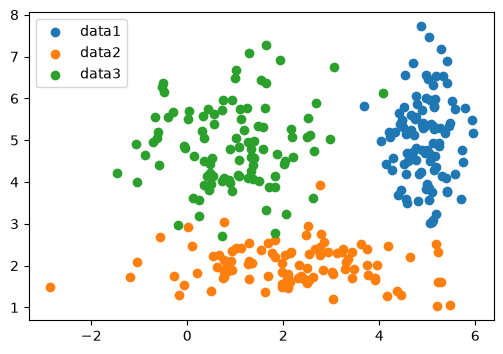

In [3]:
fig,ax=plt.subplots(figsize=(6,4))
plt.scatter(x=data1[:,0],y=data1[:,1],label='data1')
plt.scatter(x=data2[:,0],y=data2[:,1],label='data2')
plt.scatter(x=data3[:,0],y=data3[:,1],label='data3')
ax.legend()
plt.show()

In [4]:
X=np.vstack((data1,data2,data3))
X=X[np.random.choice(X.shape[0],X.shape[0],replace=False)]

In [5]:
def K_means(x,k,eps,max_iter):
    x_copy=x.copy()
    m,n=x_copy.shape
    idx=np.random.choice(range(m),k)
    mu=x_copy[idx].astype(float)
    c=np.zeros(m)
    J=0.0
    J_prev=1.0
    it=0
    while np.abs(J - J_prev) >= eps and max_iter>it:
        J_prev=J
        J=0.0 
        c=np.argmin(np.array([np.linalg.norm(x_copy-mu[j],ord=2,axis=1)**2 for j in range(k)]).T,axis=1)
        for j in range(mu.shape[0]):          
            if not (c==j).any():
                mu[j]=x_copy[np.random.randint(m)]
            else:
                mu[j]=np.mean(x_copy[c==j],axis=0)
            J+=np.sum(np.linalg.norm(x_copy[c==j]-mu[j],ord=2,axis=1)**2)
        it+=1
        if it%20==0:
            print(J)
    if np.abs(J - J_prev) < eps:
        print(f'Algorithm converged in {it} iterations')
    return c,mu

In [6]:
c,mu=K_means(X,3,1e-3,300)

Algorithm converged in 6 iterations


In [7]:
colors = ['#8AC926','#faa555', '#1982C4'] 
cmap = ListedColormap(colors)

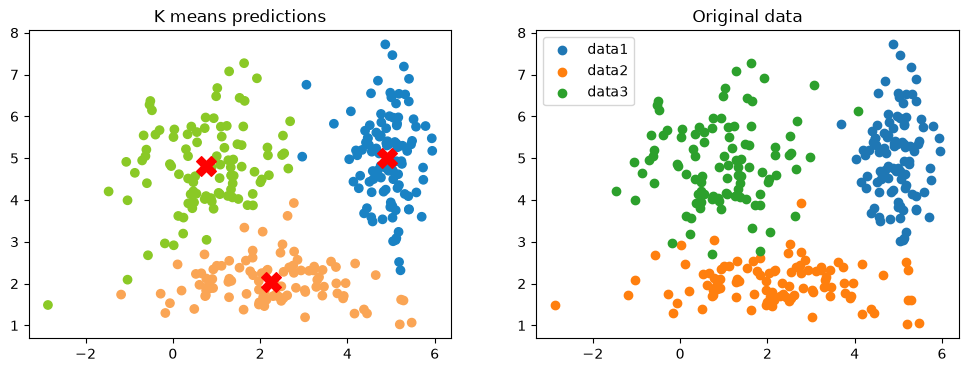

In [8]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,4))
ax1.scatter(x=X[:,0],y=X[:,1],c=c,cmap=cmap)
ax1.scatter(x=mu[:,0],y=mu[:,1],marker='X',s=200,c='r')
ax1.set_title('K means predictions')
ax2.scatter(x=data1[:,0],y=data1[:,1],label='data1')
ax2.scatter(x=data2[:,0],y=data2[:,1],label='data2')
ax2.scatter(x=data3[:,0],y=data3[:,1],label='data3')
ax2.set_title('Original data')
ax2.legend()
plt.show()